In [2]:
%pip install matplotlib

  Using cached matplotlib-3.10.9-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.7/118.7 kB 1.1 MB/s eta 0:00:00a 0:00:01
  Using cached kiwisolver-1.5.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.1 kB)
  Using cached numpy-2.4.5-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.9-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (8.8 MB)
Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (362 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 9.4 MB/s eta 0:00:0000:0100:01m
Using cache

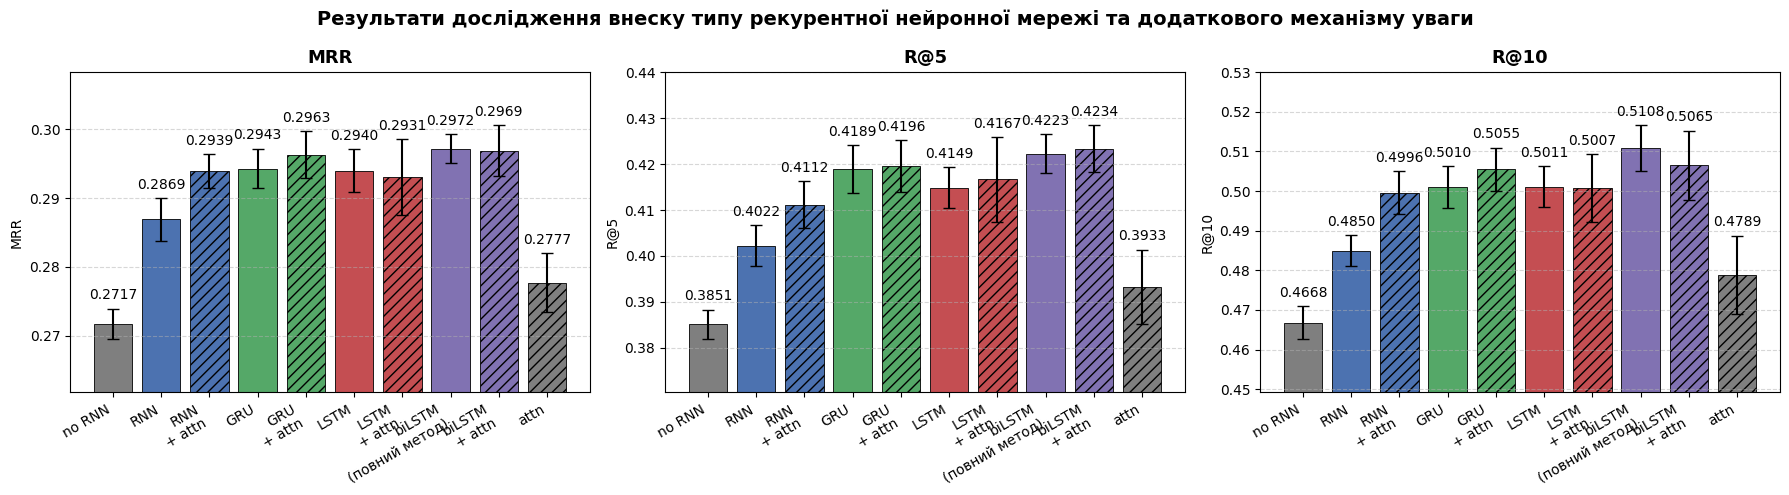

In [3]:
import matplotlib.pyplot as plt
import numpy as np

models = ['no RNN', 'RNN', 'RNN\n+ attn', 'GRU', 'GRU\n+ attn',
          'LSTM', 'LSTM\n+ attn', 'biLSTM\n(повний метод)', 'biLSTM\n+ attn',
          'attn']

mrr     = [0.2717, 0.2869, 0.2939, 0.2943, 0.2963, 0.2940, 0.2931, 0.2972, 0.2969, 0.2777]
mrr_err = [0.0022, 0.0031, 0.0025, 0.0029, 0.0034, 0.0031, 0.0055, 0.0021, 0.0037, 0.0043]

r5      = [0.3851, 0.4022, 0.4112, 0.4189, 0.4196, 0.4149, 0.4167, 0.4223, 0.4234, 0.3933]
r5_err  = [0.0032, 0.0045, 0.0051, 0.0052, 0.0056, 0.0044, 0.0092, 0.0042, 0.0051, 0.0081]

r10     = [0.4668, 0.4850, 0.4996, 0.5010, 0.5055, 0.5011, 0.5007, 0.5108, 0.5065, 0.4789]
r10_err = [0.0041, 0.0038, 0.0054, 0.0053, 0.0054, 0.0052, 0.0086, 0.0058, 0.0087, 0.0098]

metrics = [('MRR', mrr, mrr_err),
           ('R@5', r5, r5_err),
           ('R@10', r10, r10_err)]

  # 1 базовий колір для no RNN + 4 кольори по парах: RNN / GRU / uni LSTM / bi LSTM
base_colors = ['#7F7F7F', '#4C72B0', '#55A868', '#C44E52', '#8172B2']
colors = [base_colors[0]] + [c for c in base_colors[1:] for _ in range(2)] + [base_colors[0]]
  # парні (з attn) — зі штриховкою
hatches = [''] + ['', '///'] * 4 + ['///']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
x = np.arange(len(models))

for ax, (name, vals, errs) in zip(axes, metrics):
    bars = ax.bar(x, vals, yerr=errs, capsize=4, color=colors,
                  edgecolor='black', linewidth=0.6, hatch=hatches)
    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=30, ha='right')
    ax.set_ylabel(name)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

    lo = min(v - e for v, e in zip(vals, errs))
    hi = max(v + e for v, e in zip(vals, errs))
    pad = (hi - lo) * 0.25
    ax.set_ylim(lo - pad, hi + pad)

    for bar, v, e in zip(bars, vals, errs):
        ax.text(bar.get_x() + bar.get_width()/2,
                v + e + (hi - lo) * 0.03,
                f'{v:.4f}', ha='center', va='bottom', fontsize=10)

fig.suptitle('Результати дослідження внеску типу рекурентної нейронної мережі та додаткового механізму уваги',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()